# Summary

Lets fit the models to the actual data.

---
# Setup

In [5]:
# @title Imports
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from popy.plotting.plotting_tools import *
from popy.behavior_data_tools import *
from popy.config import PROJECT_PATH_LOCAL

---
# Simulated agent behavior

Processing monkey: ka


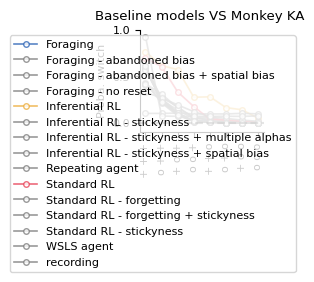

Foraging Foraging - Best target selection: 0.72 ± 0.000000
Foraging - abandoned bias Foraging - abandoned bias - Best target selection: 0.73 ± 0.000000
Foraging - abandoned bias + spatial bias Foraging - abandoned bias + spatial bias - Best target selection: 0.64 ± 0.000000
Foraging - no reset Foraging - no reset - Best target selection: 0.71 ± 0.000000
Inferential RL Inferential RL - Best target selection: 0.70 ± 0.000000
Inferential RL - stickyness Inferential RL - stickyness - Best target selection: 0.72 ± 0.000000
Inferential RL - stickyness + multiple alphas Inferential RL - stickyness + multiple alphas - Best target selection: 0.72 ± 0.000000
Inferential RL - stickyness + spatial bias Inferential RL - stickyness + spatial bias - Best target selection: 0.68 ± 0.000000
Repeating agent Repeating agent - Best target selection: 0.33 ± 0.000000
Standard RL Standard RL - Best target selection: 0.70 ± 0.000000
Standard RL - forgetting Standard RL - forgetting - Best target selection: 0.7

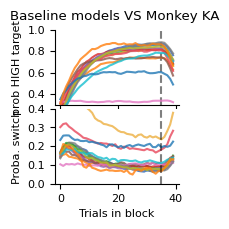

Processing monkey: po


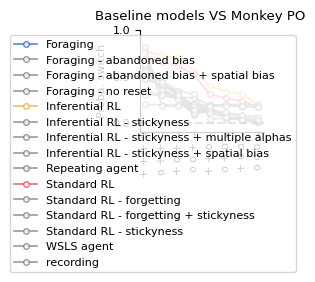

Foraging Foraging - Best target selection: 0.66 ± 0.000000
Foraging - abandoned bias Foraging - abandoned bias - Best target selection: 0.65 ± 0.000000
Foraging - abandoned bias + spatial bias Foraging - abandoned bias + spatial bias - Best target selection: 0.65 ± 0.000000
Foraging - no reset Foraging - no reset - Best target selection: 0.58 ± 0.000000
Inferential RL Inferential RL - Best target selection: 0.59 ± 0.000000
Inferential RL - stickyness Inferential RL - stickyness - Best target selection: 0.61 ± 0.000000
Inferential RL - stickyness + multiple alphas Inferential RL - stickyness + multiple alphas - Best target selection: 0.40 ± 0.000000
Inferential RL - stickyness + spatial bias Inferential RL - stickyness + spatial bias - Best target selection: 0.54 ± 0.000000
Repeating agent Repeating agent - Best target selection: 0.32 ± 0.000000
Standard RL Standard RL - Best target selection: 0.61 ± 0.000000
Standard RL - forgetting Standard RL - forgetting - Best target selection: 0.6

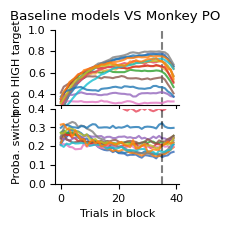

In [8]:
for monkey in ['ka', 'po']:#, 'yu_sham', 'yu_DCZ']:
    print(f'Processing monkey: {monkey}')
    floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'model_fitting', f'simulation_behaviors_{monkey}.pkl')
    behav = pd.read_pickle(floc)
    # remove n_target_touches column if exists
    if 'n_target_touches' in behav.columns:
        behav = behav.drop(columns=['n_target_touches'])

    # Apply the function to create the monkey column
    behav['monkey'] = behav['model']

    behav = convert_column_format(behav, original='simulation')

    behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1))
    behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
    behav = behav.dropna()

    fig1, _ = plot_hist_thingy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True)
    # remove legend
    plt.legend([], [], frameon=False)
    plt.show()

    fig2, _ = plot_strategy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=True, h=2, w=1.6, ylim=[0, .4], verbose=True)
    # remove legend
    plt.legend([], [], frameon=False)
    plt.show()

    plt.close(fig1)
    plt.close(fig2)